# Imports

In [1]:
import sys, os, tempfile, subprocess, shutil, mdtraj
import pandas as pd
from pathlib import Path

In [2]:
sys.path.append("..")

In [3]:
from predict import \
Cif, Pocket

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/autogluon/common/utils/utils.py:78: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [4]:
bioemu_python = "/home/fnerin/miniconda3/envs/bioemu/bin/python"

In [5]:
outdir = "bioemu_8uk6"
os.makedirs(outdir, exist_ok=True)

## Orig. structure

In [6]:
origcif = Cif("8uk6", "../training_data/7.Extra_set/origcifs/8uk6_updated.cif.gz")
origcif.residues

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res
0,PRO,A,1,233,?,214,PRO,A,1,233,UNP,A0A1D8PQM9,214,P
7,GLU,A,1,234,?,215,GLU,A,1,234,UNP,A0A1D8PQM9,215,E
16,ARG,A,1,235,?,216,ARG,A,1,235,UNP,A0A1D8PQM9,216,R
27,SER,A,1,236,?,217,SER,A,1,236,UNP,A0A1D8PQM9,217,S
33,MET,A,1,237,?,218,MET,A,1,237,UNP,A0A1D8PQM9,218,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4722,HOH,D,4,.,?,929,HOH,A,1,929,?,?,?,?
4723,HOH,D,4,.,?,930,HOH,A,1,930,?,?,?,?
4724,HOH,D,4,.,?,931,HOH,A,1,931,?,?,?,?
4725,HOH,D,4,.,?,932,HOH,A,1,932,?,?,?,?


In [7]:
origcif.residues.query("label_asym_id == 'A'")

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res
0,PRO,A,1,233,?,214,PRO,A,1,233,UNP,A0A1D8PQM9,214,P
7,GLU,A,1,234,?,215,GLU,A,1,234,UNP,A0A1D8PQM9,215,E
16,ARG,A,1,235,?,216,ARG,A,1,235,UNP,A0A1D8PQM9,216,R
27,SER,A,1,236,?,217,SER,A,1,236,UNP,A0A1D8PQM9,217,S
33,MET,A,1,237,?,218,MET,A,1,237,UNP,A0A1D8PQM9,218,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4639,ILE,A,1,808,?,789,ILE,A,1,808,UNP,A0A1D8PQM9,789,I
4647,VAL,A,1,809,?,790,VAL,A,1,809,UNP,A0A1D8PQM9,790,V
4654,SER,A,1,810,?,791,SER,A,1,810,UNP,A0A1D8PQM9,791,S
4660,LEU,A,1,811,?,792,LEU,A,1,811,UNP,A0A1D8PQM9,792,L


In [8]:
origcif.cif.data["_entity_poly"]["pdbx_seq_one_letter_code_can"].replace("\n", "")

'GSSHHHHHHSSGLVPRGSHMSTKTDISTEELVSLFSKAGFEEKKSAEIVKNKKVASALYNILGSNFPKTDDKKLSLLHQLAIHESKNGKVPNHDFIIDGIQKGDLKTALQVTEGIKYLQNNATVDKEKFDEASGVGIEITPEEAKVEISKYLDSIKTDLESKRYSILPKVLGEVKTQPSLKWAPPNLFKPILDEEFLARLGPKDERDVKKKEKKAKTPANAAATKKQDTGSEPERSMFSEGFLGDLHKPGEEPQMYPELLEEHKKFICDKVYTRFPPEPNGFLHIGHSKAIMVNFGYAQFNKGNCYLRFDDTNPEAEEEVYFNSIKEMVSWLGYKPWKITYSSDYFDELYELAIKLIKSDKAYICHCTPEEVKASRGLKEDGTLGGERVACKHRFQTVEHNLREFENMKNGKYNVGEATLRMKQDLNSPSPQMWDLVAYRVLNTPHHRTGDKWKIYPTYDFTHCLVDSFENITHSLCTTEFVLSRESYEWLCDALHVYRPAQREYGRLNLTGTIMSKRKIAKLVNEGYVRGWDDPRLYTLEGIKRRGVPPGAILSFINTLGVTTSTTNIQTVRFESAVRNYLDQTTPRLMMVLHPIEVVIDNLDESFSLDVEIPYKPGKDEKSMGYRKLTFSKHIYIDENDVRAEPADKEFYRLAPGQPVGLMRVPFNISFKSIEEKDGKKIVHVNYDEGVKAKPKTYIQWIPKDTAVHIKEVRIYNQLFKSENPSAHPEGYLKDINPDSEEVLRNAVVEENLKDIVAKSPMNIEIPGSAFNIKENKGNNTVRFQALREGYFCLDKDSKEDGLILNRIVSLKEDAAKK'

**Only modelled residues:**

In [9]:
origcif.residues["label_seq_id"].loc[lambda x: x != "."].iloc[[0, -1]].to_list()

['233', '812']

In [10]:
seq = origcif.cif.data["_entity_poly"]["pdbx_seq_one_letter_code_can"].replace("\n", "")[233-1:812]
seq

'PERSMFSEGFLGDLHKPGEEPQMYPELLEEHKKFICDKVYTRFPPEPNGFLHIGHSKAIMVNFGYAQFNKGNCYLRFDDTNPEAEEEVYFNSIKEMVSWLGYKPWKITYSSDYFDELYELAIKLIKSDKAYICHCTPEEVKASRGLKEDGTLGGERVACKHRFQTVEHNLREFENMKNGKYNVGEATLRMKQDLNSPSPQMWDLVAYRVLNTPHHRTGDKWKIYPTYDFTHCLVDSFENITHSLCTTEFVLSRESYEWLCDALHVYRPAQREYGRLNLTGTIMSKRKIAKLVNEGYVRGWDDPRLYTLEGIKRRGVPPGAILSFINTLGVTTSTTNIQTVRFESAVRNYLDQTTPRLMMVLHPIEVVIDNLDESFSLDVEIPYKPGKDEKSMGYRKLTFSKHIYIDENDVRAEPADKEFYRLAPGQPVGLMRVPFNISFKSIEEKDGKKIVHVNYDEGVKAKPKTYIQWIPKDTAVHIKEVRIYNQLFKSENPSAHPEGYLKDINPDSEEVLRNAVVEENLKDIVAKSPMNIEIPGSAFNIKENKGNNTVRFQALREGYFCLDKDSKEDGLILNRIVSLK'

## Site

In [11]:
site = pd.read_pickle("../training_data/7.Extra_set/news_sites.pkl")["8uk6"]
site

[{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
  4678           WVK             C               3            .   
  
       pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
  4678                 ?         802          WVK            A   
  
       pdbx_PDB_model_num pdbx_label_index pdbx_sifts_xref_db_name  \
  4678                  1              802                       ?   
  
       pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res  
  4678                      ?                      ?                      ?  ,
  'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0            GLY             A               1          281                 ?   
  1            PHE             A               1          282                 ?   
  2            LEU             A               1          283                 ?   
  3            HIS             A               1          284                 ?  

In [12]:
"".join(site[0]["site"]["pdbx_sifts_xref_db_res"])

'GFLHHGTIMSKIWRLYTQLFP'

In [13]:
print(tuple( site[0]["site"]["label_seq_id"] ))

('281', '282', '283', '284', '287', '512', '513', '514', '515', '516', '517', '520', '532', '536', '537', '538', '539', '718', '719', '720', '725')


In [14]:
print(tuple( site[0]["site"]["label_seq_id"].astype(int) - 233 )) # 233 is the first label_seq_id (modelled residues) used for the BioEmu seq

(48, 49, 50, 51, 54, 279, 280, 281, 282, 283, 284, 287, 299, 303, 304, 305, 306, 485, 486, 487, 492)


In [15]:
seq_ids = site[0]["site"]["label_seq_id"].astype(int) - 233
"".join(
    map(
        str,
        pd.DataFrame(list(seq)).iloc[list(seq_ids)][0]
    )
)

'GFLHHGTIMSKIWRLYTQLFP'

In [16]:
# Getting residues from the 0-indexed `seq` retrieves the correct site. For the `label_seq_id` of the BioEmu-generated PDBs, 1 must be added to each number
print(tuple(seq_ids + 1))

(49, 50, 51, 52, 55, 280, 281, 282, 283, 284, 285, 288, 300, 304, 305, 306, 307, 486, 487, 488, 493)


# MSA

In [17]:
msaf = f"{outdir}/test.a3m"

In [11]:
mmseqs = "/home/fnerin/miniconda3/envs/mmseqs/bin/mmseqs"
db = "/data/fnerin/uniref30_2302/uniref30_2302_db"

with tempfile.TemporaryDirectory() as tmpdir:    
    fastaf = f"{tmpdir}/fasta.fasta"
    with open(fastaf, "w") as fasta:
        fasta.write(f">fasta\n{seq}\n") 

    subprocess.run(
        (
            f"{mmseqs} createdb {fastaf} {tmpdir}/qdb -v 1 && "
            + f"{mmseqs} search {tmpdir}/qdb {db} {tmpdir}/result {tmpdir}/tmp  --gpu 1 --num-iterations 3 -e 0.1 --max-seqs 20000 --prefilter-mode 1 -a -v 1 && " # -s 9 ignored with GPU
            + f"{mmseqs} mvdb {tmpdir}/tmp/latest/profile_1 {tmpdir}/prof_res && "
            + f"{mmseqs} lndb {tmpdir}/qdb_h {tmpdir}/prof_res_h && "
            + f"{mmseqs} align {tmpdir}/prof_res {db} {tmpdir}/result {tmpdir}/result_realign -e 10 --max-accept 1000000 --alt-ali 10 -a -v 1 && "
            + f"{mmseqs} filterresult {tmpdir}/qdb {db} {tmpdir}/result_realign {tmpdir}/result_filter --qid 0 --qsc 0.8 --diff 0 --max-seq-id 1.0 --filter-min-enable 100 -v 1 && "
            + f"{mmseqs} result2msa {tmpdir}/qdb {db} {tmpdir}/result_filter {tmpdir}/result_msa --msa-format-mode 6 --filter-msa 1 --filter-min-enable 1000 --diff 3000 --qid 0.0,0.2,0.4,0.6,0.8,1.0 --qsc 0 --max-seq-id 0.95 -v 1 && "
            + f"cp {tmpdir}/result_msa {msaf}"
        ),
        shell=True, check=True
    )

rmdb /tmp/tmpj0mtqy8k/tmp/15183234163025015307/pref_tmp_1 

Time for processing: 0h 0m 0s 0ms
mergedbs /tmp/tmpj0mtqy8k/tmp/15183234163025015307/profile_0 /tmp/tmpj0mtqy8k/tmp/15183234163025015307/aln_1 /tmp/tmpj0mtqy8k/tmp/15183234163025015307/aln_0 /tmp/tmpj0mtqy8k/tmp/15183234163025015307/aln_tmp_1 

Merging the results to /tmp/tmpj0mtqy8k/tmp/15183234163025015307/aln_1
[=================================================================] 1 0s 0ms
Time for merging to aln_1: 0h 0m 0s 0ms
Time for processing: 0h 0m 0s 8ms
rmdb /tmp/tmpj0mtqy8k/tmp/15183234163025015307/aln_0 

Time for processing: 0h 0m 0s 0ms
rmdb /tmp/tmpj0mtqy8k/tmp/15183234163025015307/aln_tmp_1 

Time for processing: 0h 0m 0s 0ms
rmdb /tmp/tmpj0mtqy8k/tmp/15183234163025015307/pref_tmp_2 

Time for processing: 0h 0m 0s 0ms
mergedbs /tmp/tmpj0mtqy8k/tmp/15183234163025015307/profile_1 /tmp/tmpj0mtqy8k/result /tmp/tmpj0mtqy8k/tmp/15183234163025015307/aln_1 /tmp/tmpj0mtqy8k/tmp/15183234163025015307/aln_tmp_2 

Merging th

# BioEmu

In [19]:
# input_dir = Path("/path/to/input")  # folder with your batch_*.npz files
# work_dir = Path("/path/to/work")    # parent folder to collect outputs

# joined_name = "joined_output_dummy.npz"
chunks_dir = f"{outdir}/chunks"
os.makedirs(chunks_dir, exist_ok=True)


bioemu_python = "/home/fnerin/miniconda3/envs/bioemu/bin/python"

files = sorted(Path(f"{outdir}/npzs").glob("batch_*_*.npz"))
batch_size=1000

for i, chunk_idx in enumerate(range(0, len(files), batch_size)):
    group = files[chunk_idx : chunk_idx + batch_size]
    
    chunk_dir = f"{outdir}/chunk_{i}"
    os.makedirs(chunk_dir, exist_ok=True)

    for k, src in enumerate(group):
        os.symlink(f"../../{src}", f"{chunk_dir}/batch_{k:07d}_{k+1:07d}.npz")
    os.symlink(f"../npzs/sequence.fasta", f"{chunk_dir}/sequence.fasta")
    
    subprocess.run(
        f"{bioemu_python} -m bioemu.sample --sequence {msaf} --num_samples {batch_size} --batch_size_100 1 --output_dir {chunk_dir}", 
        shell=True, check=True
    )
    
    shutil.move(f"{chunk_dir}/topology.pdb", f"{chunks_dir}/topology_{i}.pdb")
    shutil.move(f"{chunk_dir}/samples.xtc", f"{chunks_dir}/samples_{i}.xtc")

    shutil.rmtree(chunk_dir)

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): huggingface.co:443
DEBUG:urllib3.connectionpool:https://huggingface.co:443 "HEAD /microsoft/bioemu/resolve/main/checkpoints/bioemu-v1.1/checkpoint.ckpt HTTP/1.1" 302 0
DEBUG:urllib3.connectionpool:https://huggingface.co:443 "HEAD /microsoft/bioemu/resolve/main/checkpoints/bioemu-v1.1/config.yaml HTTP/1.1" 307 0
DEBUG:urllib3.connectionpool:https://huggingface.co:443 "HEAD /api/resolve-cache/models/microsoft/bioemu/944333124e83f461bd644e62aa620b33957149cd/checkpoints%2Fbioemu-v1.1%2Fconfig.yaml HTTP/1.1" 200 0
INFO:bioemu.so3_sde:Data loaded from /home/fnerin/sampling_so3_cache/cache_igso3_s0.020-2.330-1000_l2000_o2000-3.npz
INFO:bioemu.so3_sde:Data loaded from /home/fnerin/sampling_so3_cache/cache_uso3_s0.020-2.330-1000_o2000-3.npz
INFO:bioemu.so3_sde:Data loaded from /home/fnerin/sampling_so3_cache/cache_score-scaling_s0.020-2.330-1000_l2001_o2000-3.npz
INFO:__main__:Sampling 1000 structures for sequence of length 580 res

In [23]:
traj = mdtraj.load([f"{chunks_dir}/{f}" for f in sorted(os.listdir(chunks_dir)) if f.endswith(".xtc")], top=f"{chunks_dir}/topology_0.pdb")
traj[0].save_pdb(f"{outdir}/topology.pdb")
traj.save_xtc(f"{outdir}/samples.xtc")

# Cluster

## foldseek

In [25]:
pdbsdir = f"{outdir}/pdbs"

In [26]:
os.makedirs(pdbsdir, exist_ok=True)

for i, frame in enumerate(mdtraj.load(f"{outdir}/samples.xtc", top=f"{outdir}/topology.pdb")):
    frame.save_pdb(f"{pdbsdir}/frame_{i}.pdb")

In [ ]:
foldseekdir = f"{outdir}/foldseek"
os.makedirs(foldseekdir, exist_ok=True)

In [31]:
tmscore_threshold = 0.7
coverage_threshold = 1
seq_id = 1
coverage_mode = 1

with tempfile.TemporaryDirectory() as temp_dir:
    res = subprocess.run(
        " ../training_data/utils/external/foldseek easy-cluster "
        + f" {outdir}/pdbs "
        + f" {foldseekdir}/cluster "
        + temp_dir
        + f" -c {coverage_threshold} "
        + f" --min-seq-id {seq_id} "
        + f" --tmscore-threshold {tmscore_threshold} "
        + f" --cov-mode {coverage_mode} "
        + f" --single-step-clustering "
        # + f" --exact-tmscore 1 ", # makes it too slow
        + f" --tmalign-fast 0 ", 
        shell=True,
    )
    assert res.returncode == 0, "Something went wrong with foldseek"

easy-cluster bioemu_8uk6/pdbs bioemu_8uk6/cluster /tmp/tmpd67m5vc0 -c 1 --min-seq-id 1 --tmscore-threshold 0.7 --cov-mode 1 --single-step-clustering --tmalign-fast 0 

MMseqs Version:                     	941cd33ff0771cd2e3f144e3293e22a2b87e9fda
Substitution matrix                 	aa:3di.out,nucl:3di.out
Seed substitution matrix            	aa:3di.out,nucl:3di.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Max sequence length                 	65535
Max results per query               	300
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	1
Coverage mode                       	1
Compositional bias                  	1
Compositional bias                  	1
Diagonal scoring                    	true
Exact k-mer matching                	0
Mask resi

In [34]:
clusters = pd.read_csv(f"{foldseekdir}/cluster_cluster.tsv", sep="\t", header=None)
clusters.value_counts(0)

0
frame_0       6820
frame_10      1215
frame_1011     259
frame_1015     216
frame_103      113
              ... 
frame_4906       1
frame_4667       1
frame_4532       1
frame_4503       1
frame_5308       1
Name: count, Length: 104, dtype: int64

In [35]:
traj = mdtraj.join([mdtraj.load_pdb(f"{pdbsdir}/{f}.pdb") for f in clusters[0].unique()])
traj[0].save(f"{foldseekdir}/foldseek.pdb")
traj.save_xtc(f"{foldseekdir}/foldseek.xtc")

## msmbuilder2022

In [19]:
msmdir = f"{outdir}/msmclust"
os.makedirs(msmdir, exist_ok=True)

In [6]:
from msmbuilder.dataset import dataset as msmdataset
from msmbuilder import featurizer as msmfeat
# from msmbuilder import cluster as msmcluster
from sklearn.cluster import Birch

# from msmbuilder.decomposition import PCA
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

In [8]:
# Create a dataset loader
ds = msmdataset(f"{outdir}/samples.xtc", topology=f"{outdir}/topology.pdb", stride=1)

In [9]:
#  -- Define various featurizers
featurizers = {
    'dihedrals': msmfeat.DihedralFeaturizer(types=['phi', 'psi'], sincos=True),
    'distances': msmfeat.ContactFeaturizer(contacts='all', scheme='ca'), # 'closest-heavy' is very slow
    # 'contacts': msmfeat.BinaryContactFeaturizer(contacts='all', scheme='closest-heavy'),
    'sasa': msmfeat.SASAFeaturizer(mode='residue')
}

In [10]:
# --- Main loop ---
results = {}

for feat_name, feat in featurizers.items():    
    msmfeatdir = f"{msmdir}/{feat_name}"
    os.makedirs(msmfeatdir, exist_ok=True)
    datadf = f"{msmfeatdir}/{feat_name}_datad.pkl"
    if os.path.isfile(datadf):
        (X_flat, X_pca, X_umap, X_pca_2d, X_tsne) = pd.read_pickle(datadf)
    else:
        start = time.time()
        X_flat = feat.transform(ds)[0]
        print(f"{feat_name} computed in {(time.time() - start):.2f} seconds")
        # Compute once per feat-cluster combo for consistent visualization
        start = time.time()
        X_pca_2d = PCA(n_components=2).fit_transform(X_flat)
        print(f"PCA computed in {(time.time() - start):.2f} seconds")
        # X_pca = PCA(n_components=0.95).fit_transform(X_flat)
        start = time.time()
        X_umap = umap.UMAP(
            # n_neighbors=30, min_dist=0, # in UMAPS doc this is recommended for clustering
            n_jobs=16 # random_state=0 # cannot use random_state for parallelism
        ).fit_transform(X_flat)
        print(f"UMAP computed in {(time.time() - start):.2f} seconds")
        start = time.time()
        X_tsne = TSNE(random_state=0, n_jobs=16).fit_transform(X_flat)
        print(f"tSNE computed in {(time.time() - start):.2f} seconds")
        pd.to_pickle((X_flat, X_pca_2d, X_umap, X_pca_2d, X_tsne), datadf)
    
    key_pca = "umap"
    
    clust_name = "birch"
    clust = Birch(n_clusters=None) # threshold=0.5, branching_factor=50,
    
    print(f"    📊 Clustering: {feat_name} + {clust_name} ({key_pca})")
    pickle_path = f"{msmfeatdir}/{feat_name}_{clust_name}_{key_pca}.pkl"
    if not os.path.isfile(pickle_path):
        try:
            start = time.time()
            labels = clust.fit_predict(X_umap)
            elapsed = time.time() - start
            n_clusters = len(np.unique(labels))
        except Exception as e:
            print(f"      ❌ Failed: {e}")
            continue
            # labels, elapsed, n_clusters = None, None, None
        # Save result dictionary
        result = {
            'feat': feat_name,
            'clusterer': clust_name,
            'pca': key_pca,
            'labels': labels,
            'elapsed_time': elapsed,
            'n_clusters': n_clusters,
            'pickle_path': pickle_path
        }
        results[(feat_name, clust_name, key_pca)] = result
        # Save pickle
        pd.to_pickle(result, pickle_path)
        
    else:
        result = pd.read_pickle(pickle_path)
        labels = result["labels"]
        n_clusters = result["n_clusters"]
        elapsed = result["elapsed_time"]
    
    print(f"      ✅ {n_clusters} clusters in {elapsed:.2f} seconds")

    # Save PCA scatter plot with colored clusters
    colors = [
        plt.get_cmap('hsv', n_clusters + 1)(i) if i >= 0 else "gray"
        for i in labels
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    ax = axes[0]
    _ = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=colors, s=2.5, alpha=0.25, edgecolors='none')
    ax.set_title("PCA"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

    ax = axes[1]
    _ = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=2.5, alpha=0.25, edgecolors='none')
    ax.set_title("UMAP"); ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

    ax = axes[2]
    _ = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, s=2.5, alpha=0.25, edgecolors='none')
    ax.set_title("t-SNE"); ax.set_xlabel("tSNE-1"); ax.set_ylabel("tSNE-2")
    
    fig.suptitle(f"{feat_name} + {clust_name} ({key_pca}) [{n_clusters} clusters]")
    plot_path = f"{msmfeatdir}/{feat_name}_{clust_name}_{key_pca}.png"
    fig.savefig(plot_path, dpi=300)
    plt.close(fig)

    📊 Clustering: dihedrals + birch (umap)
      ✅ 24 clusters in 0.10 seconds
distances computed in 7.06 seconds
PCA computed in 9.82 seconds
UMAP computed in 168.82 seconds
tSNE computed in 109.28 seconds
    📊 Clustering: distances + birch (umap)
      ✅ 37 clusters in 0.09 seconds
sasa computed in 64.76 seconds
PCA computed in 0.59 seconds
UMAP computed in 3.15 seconds
tSNE computed in 17.13 seconds
    📊 Clustering: sasa + birch (umap)
      ✅ 23 clusters in 0.09 seconds


In [13]:
# chatgpt
from pathlib import Path
from PIL import Image

pngs = sorted( png for d in os.listdir(msmdir) if os.path.isdir(f"{msmdir}/{d}") for png in Path(f"{msmdir}/{d}").glob("*.png") )
if not pngs:
    print(f"No PNGs found")
else:
    imgs = [Image.open(p).convert("RGB") for p in pngs]
    pdf_path = f"{msmdir}/all_plots_stacked.pdf"
    imgs[0].save(pdf_path, save_all=True, append_images=imgs[1:])
    print(f"Saved {pdf_path}")

Saved bioemu_8uk6/msmclust/all_plots_stacked.pdf


### Cluster reps

In [34]:
import numpy as np

def get_cluster_reps(ds, msmdir, feat_name):
    (X_flat, X_pca, X_umap, X_pca_2d, X_tsne) = pd.read_pickle(f"{msmdir}/{feat_name}/{feat_name}_datad.pkl")
    result = pd.read_pickle(f"{msmdir}/{feat_name}/{feat_name}_birch_umap.pkl")
    labels = result["labels"]
    print(result)
    
    reps = {}
    for lab in np.unique(labels):
        idx = np.where(labels == lab)[0]
        center = X_umap[idx].mean(axis=0)
        reps[lab] = idx[np.argmin(((X_umap[idx] - center)**2).sum(axis=1))]
    print(reps)
    
    reptraj = mdtraj.join([ds[0][frame] for frame in reps.values()])
    reptraj[0].save(f"{msmdir}/{feat_name}/topology.pdb")
    reptraj.save_xtc(f"{msmdir}/{feat_name}/samples.xtc")
    
    subprocess.run(
        f"{bioemu_python} -m bioemu.sidechain_relax --pdb-path {msmdir}/{feat_name}/topology.pdb --xtc-path {msmdir}/{feat_name}/samples.xtc --no-md-equil --outpath {msmdir}/{feat_name}",
        shell=True, check=True
    )

In [35]:
get_cluster_reps(ds, msmdir, "dihedrals")

{'feat': 'dihedrals', 'clusterer': 'birch', 'pca': 'umap', 'labels': array([22,  1,  2, ..., 12, 12, 21]), 'elapsed_time': 0.09807372093200684, 'n_clusters': 24, 'pickle_path': 'bioemu_8uk6/msmclust/dihedrals/dihedrals_birch_umap.pkl'}
{0: 6123, 1: 5827, 2: 8579, 3: 996, 4: 5231, 5: 7129, 6: 5218, 7: 4142, 8: 663, 9: 716, 10: 2776, 11: 3960, 12: 1937, 13: 1289, 14: 4331, 15: 1386, 16: 1484, 17: 7662, 18: 7208, 19: 2269, 20: 5416, 21: 4400, 22: 987, 23: 8805}


In [36]:
get_cluster_reps(ds, msmdir, "distances")

{'feat': 'distances', 'clusterer': 'birch', 'pca': 'umap', 'labels': array([ 0,  1,  2, ...,  2, 14, 23]), 'elapsed_time': 0.0933232307434082, 'n_clusters': 37, 'pickle_path': 'bioemu_8uk6/msmclust/distances/distances_birch_umap.pkl'}
{0: 7217, 1: 2471, 2: 2869, 3: 669, 4: 3226, 5: 7757, 6: 8161, 7: 4353, 8: 1428, 9: 6059, 10: 8171, 11: 4305, 12: 8481, 13: 2799, 14: 8130, 15: 5307, 16: 1046, 17: 5489, 18: 8580, 19: 7018, 20: 1156, 21: 4255, 22: 1715, 23: 7028, 24: 7156, 25: 5781, 26: 6802, 27: 3555, 28: 7701, 29: 5148, 30: 3614, 31: 3478, 32: 1305, 33: 4575, 34: 4046, 35: 4518, 36: 60}


In [37]:
get_cluster_reps(ds, msmdir, "sasa")

{'feat': 'sasa', 'clusterer': 'birch', 'pca': 'umap', 'labels': array([ 0,  1,  2, ...,  1,  7, 22]), 'elapsed_time': 0.09127664566040039, 'n_clusters': 23, 'pickle_path': 'bioemu_8uk6/msmclust/sasa/sasa_birch_umap.pkl'}
{0: 5324, 1: 7169, 2: 1995, 3: 6896, 4: 4911, 5: 6596, 6: 6220, 7: 6685, 8: 5510, 9: 3222, 10: 521, 11: 3046, 12: 5237, 13: 6472, 14: 344, 15: 4012, 16: 7283, 17: 6325, 18: 1112, 19: 1511, 20: 5548, 21: 7444, 22: 5643}


# Results

In [20]:
msmdir

'bioemu_8uk6/msmclust'

In [21]:
msmdir = 'bioemu_8uk6/msmclust'
import pandas as pd

In [22]:
dihs = pd.DataFrame(pd.read_pickle(f"{msmdir}/dihedrals/predictions.pkl")).T.sort_values("overlap", ascending=False)
dihs

,pocket,overlap,merge
frame_8,pocket1,1.0,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_15,pocket1,0.952381,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_0,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_7,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_22,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_23,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_17,pocket1,0.619048,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_9,pocket2,0.619048,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_1,pocket1,0.619048,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_5,pocket2,0.571429,label_comp_id label_asym_id pdbx_PDB_ins_co...


In [23]:
dists = pd.DataFrame(pd.read_pickle(f"{msmdir}/distances/predictions.pkl")).T.sort_values("overlap", ascending=False)
dists

,pocket,overlap,merge
frame_36,pocket13,0.952381,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_8,pocket5,0.714286,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_34,pocket1,0.666667,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_5,pocket2,0.666667,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_3,pocket1,0.619048,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_17,pocket5,0.571429,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_6,pocket1,0.52381,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_33,pocket1,0.52381,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_21,pocket1,0.52381,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_12,pocket2,0.47619,label_comp_id label_asym_id pdbx_PDB_ins_cod...


In [24]:
sasas = pd.DataFrame(pd.read_pickle(f"{msmdir}/sasa/predictions.pkl")).T.sort_values("overlap", ascending=False)
sasas

,pocket,overlap,merge
frame_22,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_19,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_16,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_12,pocket2,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_3,pocket2,0.761905,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_10,pocket1,0.714286,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_14,pocket3,0.52381,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_13,pocket2,0.52381,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_8,pocket2,0.52381,label_comp_id label_asym_id pdbx_PDB_ins_co...
frame_15,pocket2,0.47619,label_comp_id label_asym_id pdbx_PDB_ins_cod...


In [25]:
df = dihs.reset_index(names=["apo"]).assign(holo="8uk6").rename(columns={"overlap": "site_in_pocket"})
df

,apo,pocket,site_in_pocket,merge,holo
0,frame_8,pocket1,1.0,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6
1,frame_15,pocket1,0.952381,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6
2,frame_0,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6
3,frame_7,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6
4,frame_22,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6
5,frame_23,pocket1,0.904762,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6
6,frame_17,pocket1,0.619048,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6
7,frame_9,pocket2,0.619048,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6
8,frame_1,pocket1,0.619048,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6
9,frame_5,pocket2,0.571429,label_comp_id label_asym_id pdbx_PDB_ins_co...,8uk6


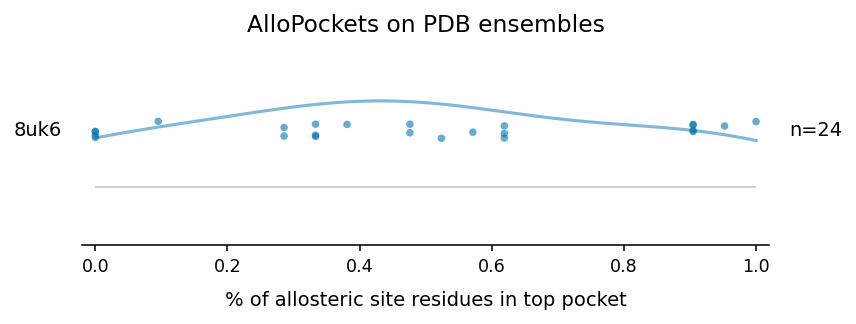

In [12]:
# Ridgeline-like plot per user spec (pure matplotlib, custom KDE, colored per holo)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You can switch which value column to plot here:
value_col = "site_in_pocket"  # or "pocket_in_site"

# ---- Utility: simple Gaussian KDE (numpy only) ----
def gaussian_kde_numpy(samples, x_grid, bw=None):
    samples = np.asarray(samples, dtype=float)
    if samples.size == 0:
        return np.zeros_like(x_grid, dtype=float)
    if bw is None:
        # Silverman's rule of thumb; fall back if std ~ 0
        std = samples.std(ddof=1) if samples.size > 1 else 0.0
        bw = 1.06 * (std if std > 1e-8 else 0.05) * (samples.size ** (-1/5))
        if bw < 1e-3:
            bw = 1e-3
    diff = (x_grid[:, None] - samples[None, :]) / bw
    # standard normal pdf
    dens = np.exp(-0.5 * diff**2) / np.sqrt(2 * np.pi)
    kde = dens.mean(axis=1) / bw
    return kde

# ---- Prepare data ----
holos = sorted(df["holo"].unique())
n_holos = len(holos)

# We’ll assume values are between 0 and 1 (as in your data)
global_min, global_max = 0.0, 1.0
x_pad_left, x_pad_right = 0.05, 0.05  # leave extra room for left/right labels
x = np.linspace(global_min, global_max, 400)

# ---- Figure ----
dpi = 140
fig_height = max(2.2, 1.0 + 0.7 * n_holos)
fig, ax = plt.subplots(figsize=(6, fig_height), dpi=dpi, constrained_layout=True)

# Visual constants
row_gap = 1.0           # distance between baselines
amp = 0.75              # max curve height within each row (keep KDE within row)
baseline_offset = 0.5   # baseline at exact row y
# point_offset = 0.08     # datapoints slightly above baseline so they are visible
lw_curve = 1.6
lw_base = 0.9
ms_points = 15

# Colorblind-friendly diverging palette (9 colors max)
palette = sns.color_palette("colorblind", n_colors=9)
colors = {h: palette[i % len(palette)] for i, h in enumerate(holos)}

# ---- Plot each row ----
for i, holo in enumerate(holos):
    subset = df.loc[df["holo"] == holo, value_col].astype(float).values
    y0 = (n_holos - 1 - i) * row_gap  # top-to-bottom ordering
    
    # KDE line (scaled to fit within row height)
    kde = gaussian_kde_numpy(subset, x)
    if np.allclose(kde.max(), 0):
        kde_scaled = np.zeros_like(kde)
    else:
        kde_scaled = (kde / kde.max()) * amp
    
    ax.plot(x, y0 + kde_scaled, linewidth=lw_curve, color=colors[holo], zorder=3, alpha=0.5)
    
    # Thin, light gray, straight horizontal baseline
    ax.hlines(y0, global_min, global_max, color="#C8C8C8", linewidth=lw_base, zorder=1) # y0 + baseline_offset
    
    # Datapoints as small circles slightly above the baseline
    if subset.size > 0:
        # Horizontal jitter (e.g., ±0.01)
        # jitter_x = np.random.uniform(-0.01, 0.01, size=subset.size)
        # Vertical jitter around the baseline offset + point_offset
        jitter_y = np.random.uniform(-0.075, 0.075, size=subset.size)
    
        ax.scatter(
            subset,# + jitter_x,
            np.full_like(subset, y0 + baseline_offset ) + jitter_y, # + point_offset
            s=ms_points,
            facecolor=colors[holo],
            edgecolor="none",
            alpha=0.6,
            zorder=4
        )
    
    # Labels: holo on the left (unrotated), n= on the right
    ax.text(global_min - x_pad_left, y0 + baseline_offset, f"{holo}",
            ha="right", va="center", fontsize=10)
    ax.text(global_max + x_pad_right, y0 + baseline_offset, f"n={subset.size}",
            ha="left", va="center", fontsize=10)

# ---- Aesthetics ----
# Axis limits leave room for labels
ax.set_xlim(global_min - x_pad_left, global_max + x_pad_right)
ax.set_ylim(-0.5, (n_holos - 1) * row_gap + amp + 0.5)

# Remove y-axis, ticks, and legend; keep a clean x-axis
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_yticks([])

# Light x-axis with subtle ticks
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(axis="x", which="both", length=3, width=0.8, labelsize=9)
ax.set_xlabel("% of allosteric site residues in top pocket", labelpad=8)
ax.set_xlim(-0.02, 1.02)
# ax.set_xmargin(0.1)

ax.set_title("AlloPockets on PDB ensembles")
# No legend or titles
# (not creating a legend; title intentionally omitted)

plt.show()


## MVS

In [24]:
import molviewspec as mvs
import json, requests, time
import numpy as np
from matplotlib.colors import to_hex

In [25]:
def get_transform(apopath:str, a:tuple) -> np.array:
    q={
      "context":{"mode":"pairwise","method":{"name":"tm-align"},"structures":[
        {"format":"mmcif","selection":{"asym_id":f'A'}},
        {"entry_id":a[0],"selection":{"asym_id":a[1]}},
      ]}
    }
    f = [("files", (apopath.rsplit("/", 1)[-1].split(".")[0], open(apopath, "r")))]
    
    u = requests.post("https://alignment.rcsb.org/api/v1/structures/submit", params={"query":json.dumps(q)}, files=f).text
    running = True
    while running:
        r=json.loads(requests.get(f"https://alignment.rcsb.org/api/v1/structures/results?uuid={u}").text)
        running = r["info"]["status"] != "COMPLETE"
        time.sleep(0.5)
    M = np.array(
        r["results"][0]["structure_alignment"][0]["transformations"][1]
    ).reshape(4,4,order="F")
    return M[:3,:3].flatten(order="F").tolist(), M[:3,3].tolist()

# get_transform(("8sgj", "A"), ("8jp0", "A"))

In [37]:
ens = "dihedrals"
startcolor = "#cccccc"
top = 1
# top3 for 7yg5, 8v81 do not really predict the target site, but enforce consensus sites

In [38]:
holo = "8uk6"
path = f"{msmdir}/{ens}"

frames = pd.DataFrame(pd.read_pickle(f"{path}/predictions.pkl")).T.sort_values("overlap", ascending=False)

refapocif = Cif('frame_0', f"{path}/predictions/frame_0/frame_0.cif")

aposres = []    
for apo in frames.index:
    preds = pd.read_pickle(f"{path}/predictions/{apo}/preds.pkl")
    apores = Cif(apo, f"{path}/predictions/{apo}/{apo}.cif").residues
    for i in range(top):
        aposres.append(
            apores.merge(
                Pocket(f"{path}/predictions/{apo}/{apo}/{apo}_out/pockets/{preds.iloc[i].name}_atm.cif").residues
            )["label_seq_id"]
        )


colors = pd.concat(aposres).value_counts().to_frame().reset_index()
steps = np.linspace(int(startcolor[1:3], 16), 0, colors["count"].max()).round().astype(int)
palette = [to_hex((v / 255, v / 255, v / 255)) for v in steps]
colors["color"] = colors["count"].map(lambda k: palette[int(k) - 1])


holocif = Cif(holo, f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz")
# holosite = extra_holos_sites[holo][0]

builder = mvs.create_builder()
structure = (
    builder
    .download(url="cif")
    .parse(format="mmcif")
    .model_structure()
)
assets = {'cif': holocif.cif.text.encode()}

builder.camera(
    **eval(
        "dict("
        + """{
    position: [25.85, 9.53, -35.51],
    target: [49.67, 21.69, 16.79],
    up: [0.91, 0, -0.41],
}""".strip()[1:-1].replace(":", "=") 
        + ")"
    )
)

proteins = (
    structure
    .component(selector=[
        mvs.ComponentExpression(**{"label_asym_id": 'A'})
    ])
    .focus()
    .representation(type="cartoon", custom={"molstar_representation_params": {"ignoreLight": True}})
    .color(color='#FFFFFF')
)

annos = f'annos_pocketres.json'
assets[annos] = json.dumps(
    [
        {'label_asym_id': r["label_asym_id"], 'label_seq_id': int(r["label_seq_id"])+233-1, 'color': r["color"]}
        for i, r in refapocif.residues.merge(colors).iterrows()
    ]
).encode()
proteins.color_from_uri(uri=annos, format='json', schema='all_atomic')




# rot, trans = get_transform(refapocif.filename, (holo, "A"))
# holostruc = (
#     builder
#     .download(url="holocif")
#     .parse(format="mmcif")
#     .model_structure()
#     .transform(rotation=rot, translation=trans)
# )
# assets['holocif'] = holocif.cif.text.encode()

(
    structure
    .component(selector=[
        mvs.ComponentExpression(**{"label_asym_id": 'C'})
    ])
    .representation(custom={"molstar_representation_params": {"ignoreLight": True}})
    .color(
        custom={
            "molstar_color_theme_name": "element-symbol",
            "molstar_color_theme_params": {
                "carbonColor": { "name": "uniform", "params": {"value": int("#1a1a1a".replace('#', ''), 16)} }
            }
        }
    )
)
# (
#     holostruc
#     .component(selector=[
#         mvs.ComponentExpression(**{"label_asym_id": f'C'})
#     ])
#     .representation(type="surface", custom={"molstar_representation_params": {"ignoreLight": True}})#, custom={"ignoreLight": True})
#     .color(color="black")
#     .opacity(opacity=0.25)
# )

Representation()

In [39]:
mvs.MVSX(
    data=builder.get_state(),
    assets=assets
).molstar_notebook(width= 1500, height= 600)

<IPython.core.display.Javascript object>

## Consensus

In [26]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay

0.416021729703137


/tmp/ipykernel_2882066/175820231.py:35: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace({'_merge': {'left_only': 0, 'both': 1}})


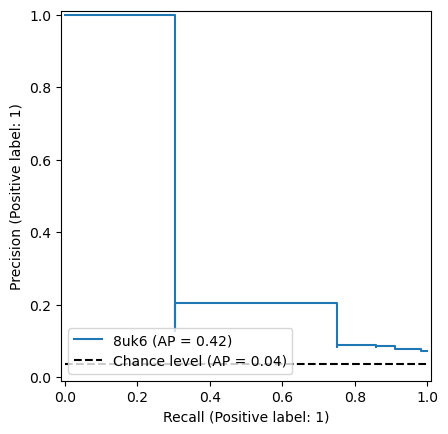

In [28]:
top = 1

holo = "8uk6"
ens = "dihedrals"
path = f"{msmdir}/{ens}"

frames = pd.DataFrame(pd.read_pickle(f"{path}/predictions.pkl")).T.sort_values("overlap", ascending=False)

refapocif = Cif('frame_0', f"{path}/predictions/frame_0/frame_0.cif")

aposres = []    
for apo in frames.index:
    preds = pd.read_pickle(f"{path}/predictions/{apo}/preds.pkl")
    apores = Cif(apo, f"{path}/predictions/{apo}/{apo}.cif").residues
    for i in range(top):
        aposres.append(
            apores.merge(
                Pocket(f"{path}/predictions/{apo}/{apo}/{apo}_out/pockets/{preds.iloc[i].name}_atm.cif").residues
            )["label_seq_id"]
        )


colors = pd.concat(aposres).value_counts().to_frame().reset_index()

holocif = Cif(holo, f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz")
holosite = site[0]

consensus = (
    holocif.residues
    .query(f"label_asym_id in {holosite['site'].label_asym_id.unique().tolist()}")
    .merge(
        holosite["site"],
        how="left", indicator=True, sort=False
    )
    .replace({'_merge': {'left_only': 0, 'both': 1}})
    .merge(
        colors, how="left", sort=False
    )
    .fillna({"count": 0})
)

assert not (consensus["_merge"] == "right_only").any()

print(average_precision_score(
    consensus["_merge"].tolist(), consensus["count"].tolist(),
    average=None, sample_weight=consensus["count"].tolist()
))

PrecisionRecallDisplay.from_predictions(
    consensus["_merge"].tolist(), consensus["count"].tolist(), 
    sample_weight=consensus["count"].tolist(),
    plot_chance_level=True, name=holo
)